In [3]:
def sliding_gc_content(dna_sequence, window_size, step=1):
    """
    Вычисляет GC-состав скользящим окном.
    """
    dna_sequence = dna_sequence.upper()
    gc_contents = []
    unknown_symbols = set('NRYSWKMBDHV')
    
    for start in range(0, len(dna_sequence) - window_size + 1, step):
        window = dna_sequence[start:start + window_size]
        
        gc_count = window.count('G') + window.count('C')
        
        known_count = 0
        for base in window:
            if base not in unknown_symbols:
                known_count += 1
        
        if known_count > 0:
            gc_content = gc_count / known_count
        else:
            gc_content = 0.5 
        
        gc_contents.append(gc_content)
    
    return gc_contents


def read_fasta(file_path):
    """
    Читает последовательность ДНК из FASTA файла.
    """
    sequence = ""  # <--- ИСПРАВЛЕНО: добавил = ""
    try:
        with open(file_path, 'r') as file:
            for line in file:
                line = line.strip()
                if not line.startswith('>'):
                    sequence += line
        return sequence.upper()
    except FileNotFoundError:
        print(f"Ошибка: Файл '{file_path}' не найден!")
        return None


file_path = input("Введите путь к FASTA файлу: ").strip()

dna_sequence = read_fasta(file_path)

if dna_sequence is not None:
    print(f"\nФайл успешно загружен!")
    print(f"Длина последовательности: {len(dna_sequence):,} нуклеотидов")
    print(f"Первые 100 нуклеотидов: {dna_sequence[:100]}...")
    
    print("\n" + "="*50)
    window_size = int(input("Введите размер окна (рекомендуется 10-1000): ") or "10")
    step = int(input("Введите шаг окна (рекомендуется 1-100): ") or "2")
    
    print("\nВыполняется анализ...")
    gc_scores = sliding_gc_content(dna_sequence, window_size, step)
    
    print(f"\nВсего окон: {len(gc_scores)}")
    print(f"GC-состав первых 5 окон: {[round(x, 4) for x in gc_scores[:5]]}")
    print(f"GC-состав последних 5 окон: {[round(x, 4) for x in gc_scores[-5:]]}")
else:
    print("Не удалось загрузить последовательность. Программа завершена.")

Введите путь к FASTA файлу:  C:\Users\Евдокия\Downloads\sequence.fasta



Файл успешно загружен!
Длина последовательности: 14,036 нуклеотидов
Первые 100 нуклеотидов: ATTAGTTCTTTTGGATAATGTTGGTGTAATGTGTCATTCCTTAAGAATTCTACTGTTATATACCATTTTTATTAAGGTCATTGCAATAAATAAACATGAA...



Введите размер окна (рекомендуется 10-1000):  100
Введите шаг окна (рекомендуется 1-100):  10



Выполняется анализ...

Всего окон: 1394
GC-состав первых 5 окон: [0.26, 0.28, 0.27, 0.27, 0.25]
GC-состав последних 5 окон: [0.44, 0.44, 0.41, 0.36, 0.33]


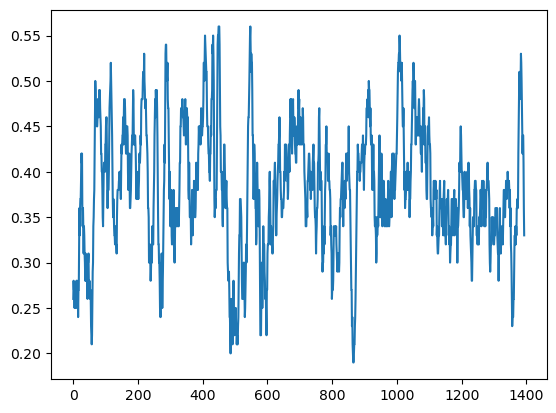

In [4]:
import matplotlib.pyplot as plt 

plt.plot(gc_scores)